# Comparison between the different altimetric product
- surface + 15m depth
- $\Delta T$<3h
- Gradient compute from the duacs speed


In [5]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby, compute_variance, extract_mean_geo

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

# Generate

In [2]:
dt = 3
distance_to_coast_max = 20e3

In [36]:
# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = '',
        drifter_preprocess_param='',
        alti_product_key='swot250m',
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')


comb_list = [ 
    update_dict(base_dic, {'alti_diff_method':'xarray_diff', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_diff_method':'xarray_diff', 'ggd_var':'etaf'}), 
    update_dict(base_dic, {'alti_diff_method':'diff_only', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_diff_method':'diff_only', 'ggd_var':'etaf'}), 
    base_dic, 
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'xarray_diff', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'xarray_diff', 'ggd_var':'etaf'}),
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'diff_only', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'diff_only', 'ggd_var':'etaf'}),
    update_dict(base_dic, {'alti_product_key':'swot2km'}), 
    update_dict(base_dic, {'alti_product_key':'L4_noswot_regional'}),
    update_dict(base_dic, {'alti_product_key':'L4_noswot_global'}),
    update_dict(base_dic, {'alti_product_key':'L4_withnadirswot'}),
]

l = [
    'L3-250m-xr-etac',
    'L3-250m-xr-etaf',
    'L3-250m-stencil-etac',
    'L3-250m-stencil-etaf',
    'L3-250m-duacsv',
    'L3-2km-xr-etac',
    'L3-2km-xr-etaf',
    'L3-2km-stencil-etac',
    'L3-2km-stencil-etaf',
    'L3-2km-duacsv',
    'L4-no-SWOT-regional-duacsv',
    'L4-no-SWOT-global-duacsv',
    'L4-SWOT-nadir-duacsv']


ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',l)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
base_dic = dict(dt='12h', 
            drifter_preprocess = '',
            drifter_preprocess_param='',
            alti_product_key='swot250m',
            alti_diff_method = 'fromduacsv',
            alti_diff_method_param = '',
            ggd_var = 'fromduacsv',
            wd_product_key = 'era5', 
            wd_model ='rio', 
            wd_depth = '15')
comb_list = [ 
    update_dict(base_dic, {'alti_diff_method':'xarray_diff', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_diff_method':'xarray_diff', 'ggd_var':'etaf'}), 
    update_dict(base_dic, {'alti_diff_method':'diff_only', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_diff_method':'diff_only', 'ggd_var':'etaf'}), 
    base_dic, 
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'xarray_diff', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'xarray_diff', 'ggd_var':'etaf'}), 
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'diff_only', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'diff_only', 'ggd_var':'etaf'}), 
    update_dict(base_dic, {'alti_product_key':'swot2km'}), 
    update_dict(base_dic, {'alti_product_key':'L4_noswot_regional'}),
    update_dict(base_dic, {'alti_product_key':'L4_noswot_global'}),
    update_dict(base_dic, {'alti_product_key':'L4_withnadirswot'}),
]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',l)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

358076
12h_spectral_decomp_all_med_variational_10min_v0____swot250m_xarray_diff__etac__era5_rio0
357404
12h_spectral_decomp_all_med_variational_10min_v0____swot250m_xarray_diff__etaf__era5_rio0
348264
12h_spectral_decomp_all_med_variational_10min_v0____swot250m_diff_only__etac__era5_rio0
343968
12h_spectral_decomp_all_med_variational_10min_v0____swot250m_diff_only__etaf__era5_rio0
349647
12h_spectral_decomp_all_med_variational_10min_v0____swot250m_fromduacsv__fromduacsv__era5_rio0
303001
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_xarray_diff__etac__era5_rio0
300939
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_xarray_diff__etaf__era5_rio0
221705
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_diff_only__etac__era5_rio0
214210
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_diff_only__etaf__era5_rio0
307771
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is avail

In [71]:
DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
#DS = DS.where((abs(DS.ggde)<1e-4) & (abs(DS.ggdn)<1e-4), drop=True)
DS = DS.where(DS.distance_to_coast>distance_to_coast_max, drop=True)

DS_nogeocor = DS.where(abs(DS.ggde.mean('row_number')/DS.ggde.std('row_number'))<=0.1, drop=True)
ds_nogeocor = compute_mean_square(DS_nogeocor)/U2

DS_geocor = extract_mean_geo(DS.where(abs(DS.ggde.mean('row_number')/DS.ggde.std('row_number'))>0.1, drop=True), dirname = ('e', 'n'))
ds_geocor = compute_mean_square(DS_geocor)/U2

ds = xr.concat([ds_nogeocor, ds_geocor], dim='id_comb')

# Closure figs
df = ds.to_dataframe()
df = df.reset_index().rename(columns={'id_comb':'Altimetric product'}).set_index('Altimetric product')


ok


In [68]:
DS.ggde.mean('row_number')/DS.ggde.std('row_number')

<xarray.DataArray 'ggde' (id_comb: 13)> Size: 104B
array([-0.00594827, -0.14062895, -0.00678985, -0.14169725, -0.19741786,
       -0.14164127, -0.17015333, -0.1430725 , -0.17026439, -0.2601946 ,
       -0.40299458, -0.38254858, -0.35646066])
Coordinates:
  * id_comb  (id_comb) <U26 1kB 'L3-250m-xr-etac' ... 'L4-SWOT-nadir-duacsv'

In [25]:
ds.to_netcdf(os.path.join(zarr_dir, 'diag_files', f'alticomp.nc'))

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


In [19]:
ds = xr.open_dataset(os.path.join(zarr_dir, 'diag_files', f'alticomp.nc'))
df = ds.to_dataframe()
df = df.reset_index().rename(columns={'id_comb':'Altimetric product'}).set_index('Altimetric product')

# Closure figs
print(DSS.sizes['row_number'])
for c in df.index :
    plt.rcParams["axes.edgecolor"] = "w"
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 10])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 10])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', '15m_' + c + '.png'))


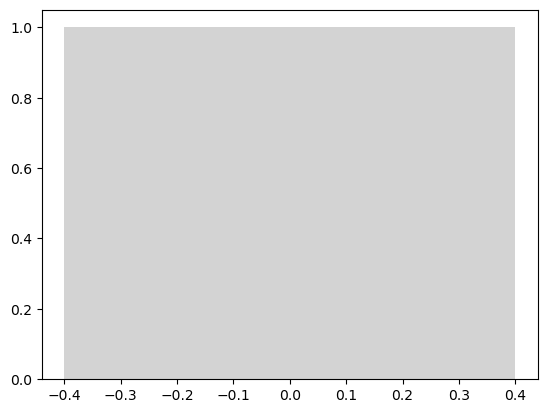

In [72]:
fig, ax=plt.subplots()
#ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
#ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0,1, color=c0['ggd'], label='Balanced signal contribution')
#ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()


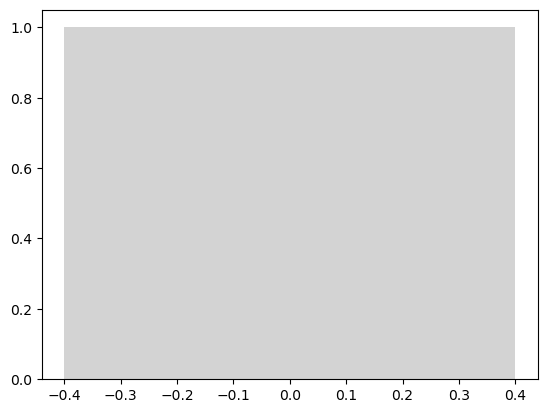

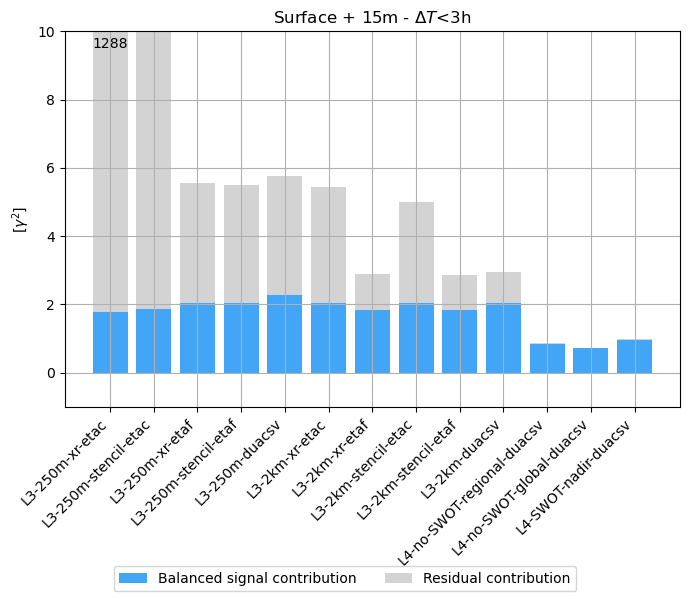

In [73]:
fig, ax=plt.subplots()
#ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
#ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0,1, color=c0['ggd'], label='Balanced signal contribution')
#ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()


# Alti comparison
fig, ax = plt.subplots(frameon=False, figsize=(7, 6))
plt.rcParams["axes.edgecolor"] = "k"
for i in range(len(df)):
    df_ = df.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd>0: ax.bar(i, df_.E_ggd, bottom = df_.B_ggd,color = 'lightgrey')
    else: ax.bar(i, df_.E_ggd,color = 'lightgrey')
    ax.bar(i, df_.B_ggd,color = c0['ggd'])

    #plt.rcParams["hatch.color"] = c0['ggd']
    #ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    #ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    #ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)
    
ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45, ha='right' )
ax.set_title(rf'Surface + 15m - $\Delta T$<{dt}h')
ax.set_ylim(-1,10)
ax.annotate(f'{round(df.iloc[0].E_ggd+df.iloc[0].B_ggd)}', (0,9.5), ha='center')
fig.tight_layout(rect=[0, 0.02, 1, 1])
fig.legend(handles, labels, ncol=3, loc="lower center")
#fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd.png'))


In [74]:
DS[['accn', 'ggdn', 'corn', 'wdn']].mean('row_number')/DS[['accn', 'ggdn', 'corn', 'wdn']].std('row_number') 

<xarray.Dataset> Size: 2kB
Dimensions:  (id_comb: 13)
Coordinates:
  * id_comb  (id_comb) <U26 1kB 'L3-250m-xr-etac' ... 'L4-SWOT-nadir-duacsv'
Data variables:
    accn     (id_comb) float64 104B -0.07236 -0.07236 ... -0.07236 -0.07236
    ggdn     (id_comb) float64 104B -0.02103 -0.1299 -0.0227 ... -0.4202 -0.3501
    corn     (id_comb) float64 104B 0.1052 0.1052 0.1052 ... 0.1052 0.1052
    wdn      (id_comb) float64 104B 0.2037 0.2037 0.2037 ... 0.2037 0.2037

In [75]:
v=['accn', 'ggdn', 'corn', 'wdn', 'acce', 'ggde', 'core', 'wde']
(DS[v]**2).mean('row_number')/DS[v].var('row_number') 

<xarray.Dataset> Size: 2kB
Dimensions:  (id_comb: 13)
Coordinates:
  * id_comb  (id_comb) <U26 1kB 'L3-250m-xr-etac' ... 'L4-SWOT-nadir-duacsv'
Data variables:
    accn     (id_comb) float64 104B 1.005 1.005 1.005 ... 1.005 1.005 1.005
    ggdn     (id_comb) float64 104B 1.0 1.017 1.001 1.017 ... 1.133 1.177 1.123
    corn     (id_comb) float64 104B 1.011 1.011 1.011 ... 1.011 1.011 1.011
    wdn      (id_comb) float64 104B 1.042 1.042 1.042 ... 1.042 1.042 1.042
    acce     (id_comb) float64 104B 1.003 1.003 1.003 ... 1.003 1.003 1.003
    ggde     (id_comb) float64 104B 1.0 1.02 1.0 1.02 ... 1.162 1.146 1.127
    core     (id_comb) float64 104B 1.074 1.074 1.074 ... 1.074 1.074 1.074
    wde      (id_comb) float64 104B 1.109 1.109 1.109 ... 1.109 1.109 1.109

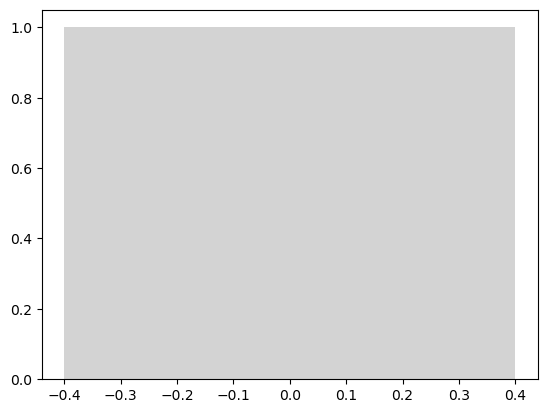

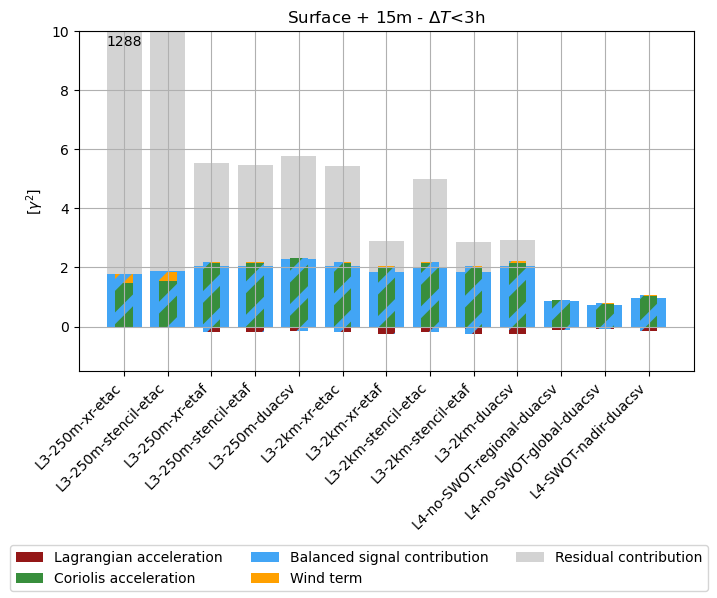

In [78]:
fig, ax=plt.subplots()
ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0,1, color=c0['ggd'], label='Balanced signal contribution')
ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()


# Alti comparison
fig, ax = plt.subplots(frameon=False, figsize=(7, 6))
plt.rcParams["axes.edgecolor"] = "k"
for i in range(len(df)):
    df_ = df.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd>0: ax.bar(i, df_.E_ggd, bottom = df_.B_ggd,color = 'lightgrey')
    else: ax.bar(i, df_.E_ggd,color = 'lightgrey')
    ax.bar(i, df_.B_ggd,color = c0['ggd'])

    plt.rcParams["hatch.color"] = c0['ggd']
    ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)
    
ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45,ha='right' )
ax.set_title(rf'Surface + 15m - $\Delta T$<{dt}h')
ax.set_ylim(-1.5,10)
ax.annotate(f'{round(df.iloc[0].E_ggd+df.iloc[0].B_ggd)}', (0,9.5), ha='center')
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.legend(handles, labels, ncol=3, loc="lower center")
#fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd.png'))


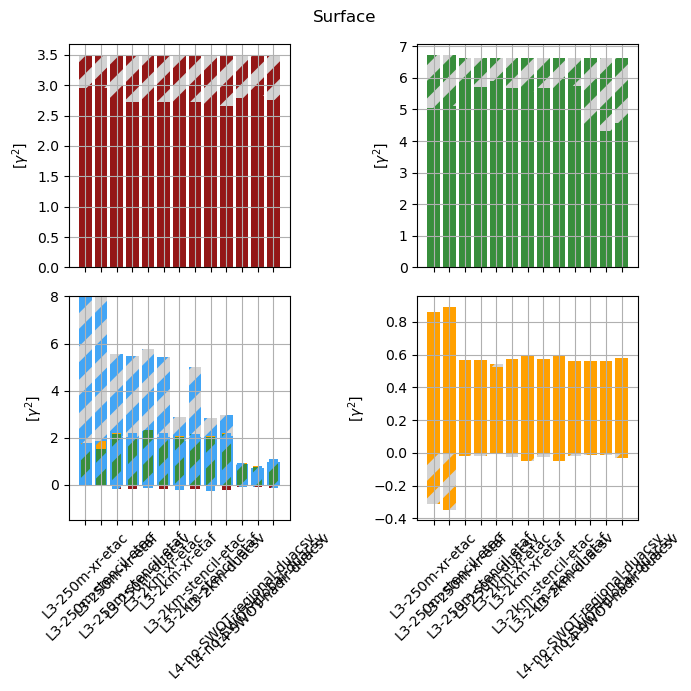

In [79]:
# Alti comparison
vars = ['acc', 'cor', 'ggd','wd']
plt.rcParams["axes.edgecolor"] = "k"
fig, axs = plt.subplots(2, 2, figsize = (7, 7), frameon=False, sharex=True)
axs = axs.flatten()
for i in range(len(df)):
    df_ = df.iloc[i]
    plt.rcParams["hatch.linewidth"] = 8
    for j in range(4):
        ax=axs[j]
        # residual contribution
        plt.rcParams["hatch.color"] = "lightgrey"
        if df_['E_'+vars[j]]>0: ax.bar(i, df_['E_'+vars[j]], bottom = df_['B_'+vars[j]],color = c0[vars[j]], hatch="/")
        else: ax.bar(i, df_['E_'+vars[j]], color = c0[vars[j]], hatch="/")
        ax.bar(i, df_['B_'+vars[j]],color = c0[vars[j]])


    ax = axs[2]
    plt.rcParams["hatch.color"] = c0['ggd']
    ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.6)
    ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.6)
    ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.6)

for ax in axs :    
    ax.grid()
    ax.set_ylabel(r'[$\gamma^2$]')
    ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45 )

axs[2].set_ylim(-1.5,8)
fig.suptitle('Surface')
fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_all.png'))
